In [23]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import lil_matrix
from itertools import product


In [24]:
from pathlib import Path
file_path = Path("../data/project_3_graph.graphml")

In [25]:
G = nx.read_graphml(file_path)

In [26]:
def build_biadjacency(G, person_nodes, other_nodes):
    """
    Build a bi-adjacency matrix B of shape (len(person_nodes), len(other_nodes)).
    B[i, j] = 1 if person i is connected to node j in G.
    """
    p_idx = {n: i for i, n in enumerate(person_nodes)}
    o_idx = {n: i for i, n in enumerate(other_nodes)}

    B = lil_matrix((len(person_nodes), len(other_nodes)), dtype=float)

    for p, o in product(person_nodes, other_nodes):
        if G.has_edge(p, o) or G.has_edge(o, p):
            B[p_idx[p], o_idx[o]] = 1.0

    return B.tocsr()  # convert to CSR for efficient matrix ops

In [27]:
def one_mode_projection(G):
    """
    Project a heterogeneous graph G onto a Person-Person graph using
    bi-adjacency matrix multiplication: P = B @ B.T

    An edge (u, v) exists in the projection if u and v co-participate
    in at least one thread or channel.
    """
    # --- 1. Partition nodes by type ---
    person_nodes  = [n for n, d in G.nodes(data=True) if G.nodes[n].get("node_type") == "person"]
    thread_nodes  = [n for n, d in G.nodes(data=True) if G.nodes[n].get("node_type") == "thread"]
    channel_nodes = [n for n, d in G.nodes(data=True) if G.nodes[n].get("node_type") == "channel"]

    # --- 2. Build bi-adjacency matrices ---
    B_thread  = build_biadjacency(G, person_nodes, thread_nodes)   # shape: P x T
    B_channel = build_biadjacency(G, person_nodes, channel_nodes)  # shape: P x C
    A_person = build_biadjacency(G, person_nodes, person_nodes)

    # --- 3. One-mode projection: P = B @ B.T ---
    P_thread  = B_thread  @ B_thread.T   # shape: P x P
    P_channel = B_channel @ B_channel.T  # shape: P x P
    P_person = A_person

    # --- 4. Combine both projections ---
    P_combined = P_thread + P_channel + P_person    # total shared contexts

    # --- 5. Build the projected NetworkX graph ---
    proj_G = nx.Graph()

    # Add all person nodes, preserving their original attributes
    for n in person_nodes:
        proj_G.add_node(n, **G.nodes[n])

    # Add edges where weight > 0, skipping self-loops (diagonal)
    P_combined = P_combined.toarray()
    for i, u in enumerate(person_nodes):
        for j, v in enumerate(person_nodes):
            if i >= j:          # upper triangle only (undirected)
                continue
            w = P_combined[i, j]
            if w > 0:
                proj_G.add_edge(u, v)

    return proj_G

In [28]:
proj_G = one_mode_projection(G)

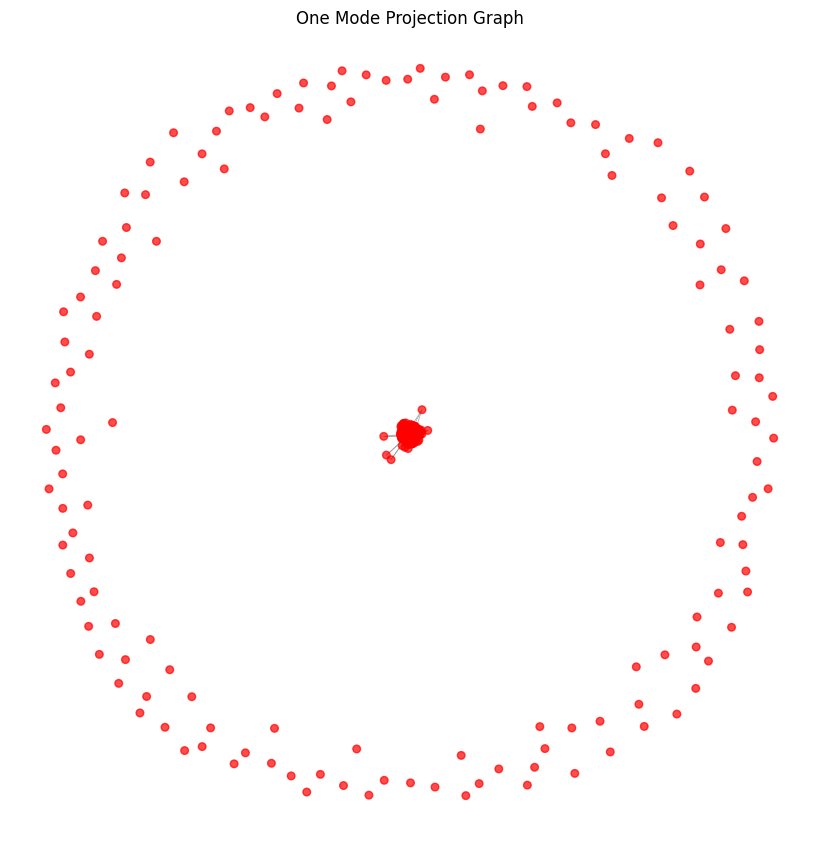

In [37]:
def plot_graph(graph, title):
    pos = nx.spring_layout(graph)

    def node_color(node_type: str):
        if node_type == "person":
            return "red"
        elif node_type == "thread":
            return "skyblue"
        elif node_type == "channel":
            return "purple"
        else:
            return "yellow"

    node_colors = [ node_color(graph.nodes[n].get("node_type")) for n in graph.nodes]

    plt.figure(figsize=(8, 8))
    nx.draw(graph, pos, node_color=node_colors, node_size=30, edge_color="gray", alpha=0.7, width=0.5)
    plt.title(title)
    plt.show()

plot_graph(proj_G, "One Mode Projection Graph")

Removed 141 isolated nodes, 174 remain


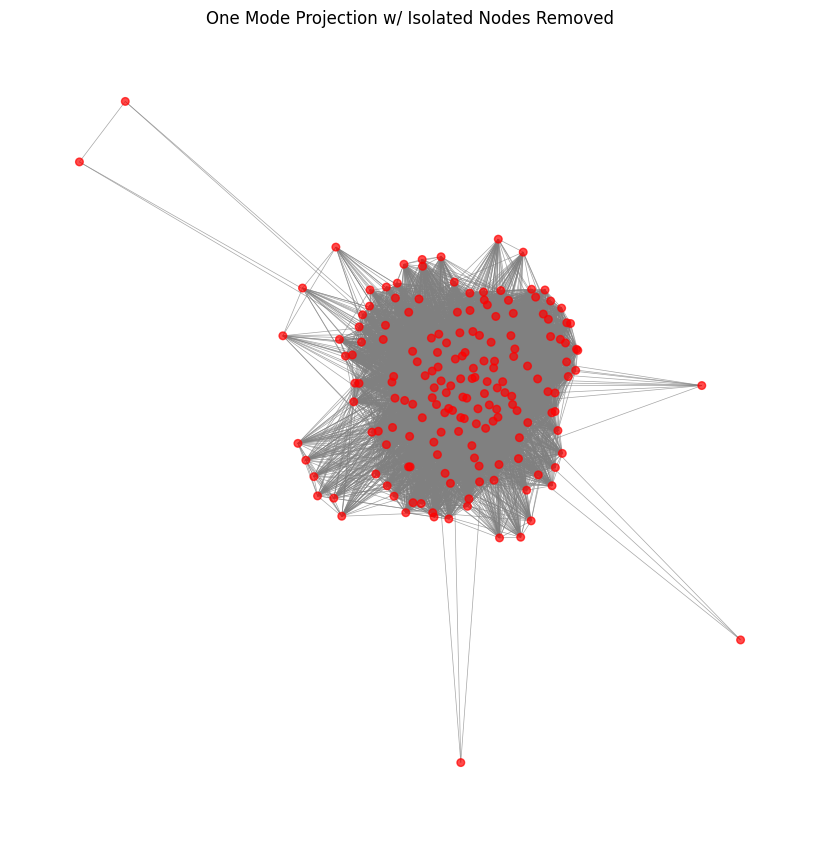

In [38]:
# Remove isolated nodes (no edges)
connected_projection_graph = proj_G.copy()

isolates = list(nx.isolates(connected_projection_graph))
connected_projection_graph.remove_nodes_from(isolates)
print(f"Removed {len(isolates)} isolated nodes, {connected_projection_graph.number_of_nodes()} remain")

plot_graph(connected_projection_graph, "One Mode Projection w/ Isolated Nodes Removed")

In [9]:
nx.write_graphml(proj_G, "../data/projected_graph.graphml")

In [32]:
nx.write_graphml(connected_projection_graph, "../data/connected_projection_graph.graphml")